**PROJECT NAME**

Supermarket Sales Transaction Prediction

**Problem Statement** 

Most supermarket operations yields very little profit margins which is as a result of high costs of maintaining excess inventory and the operational bottlenecks caused by labor shortages. Building a predictive model for total price will help to identify data-backed strategies that will minimize operational delays, optimize staffing, and reduce holding expenses or excess products.

**Proposed Solution**

The objective of this project is to build a machine learning model to forecast the total sales per transaction based on historical data. By accurately forecasting transaction values, management can optimize shelf-stocking, predict peak revenue periods, and tailor staff allocations to high-value hours.

**Dataset Description**

This dataset records individual transactions from a supermarket chain in Myanmar, with detailed attributes for each sale. The data includes the following columns:

- **Invoice ID**: Unique identifier for each transaction.
- **Branch**: The branch location of the supermarket (e.g., Yangon, Naypyitaw, Mandalay).
- **City**: The city in which the supermarket branch is located.
- **Customer Type**: Indicates whether the customer is a 'Member' or 'Normal'.
- **Gender**: Gender of the customer.
- **Product Line**: The category of the product sold (e.g., Health & Beauty, Electronic Accessories, Home & Lifestyle).
- **Unit Price**: Price per unit of the product.
- **Quantity**: Number of items purchased.
- **Tax 5%**: Calculated tax amount on the transaction at a 5% rate.
- **Total**: Total amount for the transaction including tax.
- **Date**: Date of the transaction.
- **Time**: Time of the transaction.
- **Payment**: Payment method used (e.g., Cash, Ewallet, Credit card).
- **COGS**: Cost of goods sold, representing the raw cost of the products.
- **Gross Margin Percentage**: Fixed percentage of profit for each sale (4.7619%).
- **Gross Income**: Profit earned from the transaction.
- **Rating**: Customer satisfaction rating (out of 10).

**Import Libraries**

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

**Loading Dataset**

In [8]:
df = pd.read_csv('SuperMarket Analysis.csv')

In [9]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


**EDA**

Dataset Inspection

In [12]:
# Checking the First 5 rows
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [13]:
# Checking the Last 5 rows
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,1:28:00 PM,Cash,618.38,4.761905,30.9190,6.6


In [14]:
# Checking the shape of the dataset
df.shape

(1000, 17)

In [15]:
# Checking the datatype of each column
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [16]:
# Checking the Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [17]:
# Checking the column names
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [18]:
# Checking missing values
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [19]:
# Checking for duplicate rows
df.duplicated().sum()

0

In [20]:
# Checking for Value counts of each column
for col in df.columns:
    print("=" * 40)
    print(f"Value counts for column: {col}")
    print("=" * 40)
    print(df[col].value_counts())

Value counts for column: Invoice ID
Invoice ID
750-67-8428    1
642-61-4706    1
816-72-8853    1
491-38-3499    1
322-02-2271    1
              ..
633-09-3463    1
374-17-3652    1
378-07-7001    1
433-75-6987    1
849-09-3807    1
Name: count, Length: 1000, dtype: int64
Value counts for column: Branch
Branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64
Value counts for column: City
City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64
Value counts for column: Customer type
Customer type
Member    565
Normal    435
Name: count, dtype: int64
Value counts for column: Gender
Gender
Female    571
Male      429
Name: count, dtype: int64
Value counts for column: Product line
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64
Value counts for column: Unit price
Unit price
83.77 

**Observation**
- We have 1000 rows and 17 columns in this dataset
- Date and Time columns should be converted to DateTime data type
- All other columns has the right data type
- COGS can be confusing, it's better called amount
- The column names reflects the right data in them aside the COGS that is abit confusing.
- There are no missing values recorded in the dataset
- There are also no duplicate rows in the dataset

Therefore, We will 
- rename the COGS to Amount to better represent the column
- convert the Date and Time columns to DateTime data type

Data Cleaning

In [36]:
# Convert Date and Time columns from Object to DateTime data type
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p')

In [38]:
# Confirming if the changes have been applied
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Sales                             float64
Date                       datetime64[ns]
Time                       datetime64[ns]
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [40]:
# Renaming COGS to Amount
df.rename(columns={"cogs": "Amount"}, inplace=True)

In [42]:
# Confirming the changes
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'Amount', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

Data Visualization

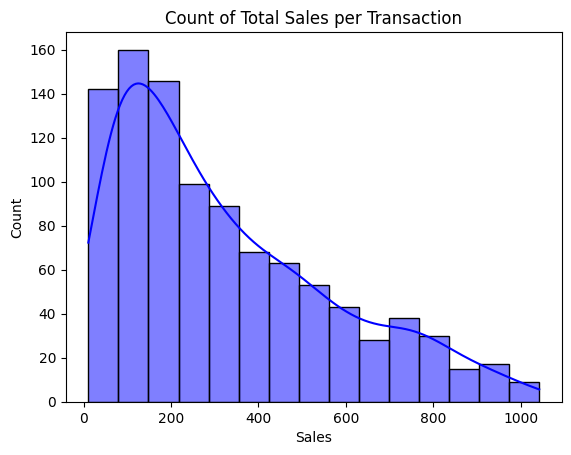

In [46]:
# Target Variable Distribution
plt.figure()
sns.histplot(df['Sales'], kde=True, color='blue')
plt.title('Count of Total Sales per Transaction')
plt.xlabel('Sales')
plt.show()

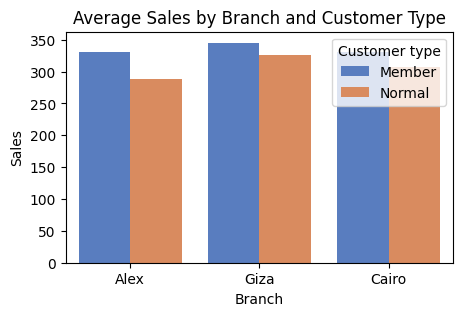

In [49]:
# Average Sales by Branch and Customer Type
plt.figure(figsize=(5, 3))
sns.barplot(x='Branch', y='Sales', hue='Customer type', data=df, palette='muted', errorbar=None)
plt.title('Average Sales by Branch and Customer Type')
plt.show()


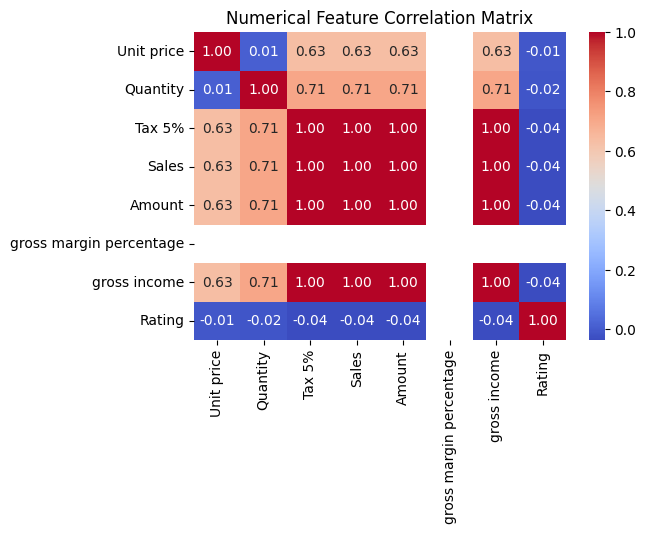

In [51]:
# Correlation Matrix for Numerical Variables
plt.figure(figsize=(6, 4))
numerical_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Matrix')
plt.show()

- Tax 5%, Sales, Amount, and gross income are perfectly correlated (1.00) to the target variable (Sales). There is a data leak in the Tax and Gross Income and we must drop them because they act as a leakage that may ruin machine learning training.
- There is strong positive correlation Quantity (0.71) with sales, and Unit price (0.63) with Sales. 
- Gross Margin Percentage has a correlation of 0 because its value never changes. It has to be dropped completely because it offers zero predictive power.



After the exploration, the following columns will be dropped to avoid data leakage and model learning on noise:
- Invoice ID
- Tax 5%
- Amount
- Gross Margin Percentage
- Gross Income
- Date
- Time

Whiile the following columns will be used to build the model
- Branch
- City
- Customer Type
- Gender
- Product line
- Unit Price
- Quantity
- Payment
- Rating
- Hour
- DayOfWeek
- Month

Wherea the target variable (Sales) will be set to y

**Feature Engineering**

In [57]:
# Extract temporal features from Date and Time
df['Hour'] = df['Time'].apply(lambda x: x.hour)
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

In [59]:
df.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,Amount,gross margin percentage,gross income,Rating,Hour,DayOfWeek,Month
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,13,5,1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,10,4,3


In [61]:
# dropping the irrelevant columns
df_ml = df.drop(columns=['Invoice ID', 'Tax 5%', 'Amount', 'gross margin percentage', 
                      'gross income', 'Date', 'Time'])

In [63]:
df_ml.shape

(1000, 13)

In [390]:
df_ml

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Sales,Payment,Rating,Hour,DayOfWeek,Month
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,548.9715,Ewallet,9.1,13,5,1
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,80.2200,Cash,9.6,10,4,3
2,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,340.5255,Credit card,7.4,13,6,3
3,Alex,Yangon,Member,Female,Health and beauty,58.22,8,489.0480,Ewallet,8.4,20,6,1
4,Alex,Yangon,Member,Female,Sports and travel,86.31,7,634.3785,Ewallet,5.3,10,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,42.3675,Ewallet,6.2,13,1,1
996,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,1022.4900,Ewallet,4.4,17,5,3
997,Alex,Yangon,Member,Male,Food and beverages,31.84,1,33.4320,Cash,7.7,13,5,2
998,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,69.1110,Cash,4.1,15,4,2


In [137]:
df["Month"].value_counts()

Month
1    352
3    345
2    303
Name: count, dtype: int64

In [119]:
df_ml.describe()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Sales,Payment,Rating,Hour,DayOfWeek,Month
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,0.988000,1.008000,0.435000,0.429000,2.452000,55.672130,5.510000,322.966749,1.001000,6.97270,14.910000,3.032000,1.993000
std,0.817633,0.820127,0.496005,0.495181,1.715412,26.494628,2.923431,245.885335,0.830475,1.71858,3.186857,1.973543,0.835254
min,0.000000,0.000000,0.000000,0.000000,0.000000,10.080000,1.000000,10.678500,0.000000,4.00000,10.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,1.000000,32.875000,3.000000,124.422375,0.000000,5.50000,12.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,2.000000,55.230000,5.000000,253.848000,1.000000,7.00000,15.000000,3.000000,2.000000
75%,2.000000,2.000000,1.000000,1.000000,4.000000,77.935000,8.000000,471.350250,2.000000,8.50000,18.000000,5.000000,3.000000
max,2.000000,2.000000,1.000000,1.000000,5.000000,99.960000,10.000000,1042.650000,2.000000,10.00000,20.000000,6.000000,3.000000


In [77]:
# Identify numerical and categorical features for preprocessing pipeline
categorical_features = df_ml.select_dtypes(include=['object']).columns.tolist()
numerical_features = df_ml.select_dtypes(include=[np.number]).columns.tolist()

In [79]:
categorical_features

['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

In [81]:
numerical_features

['Unit price', 'Quantity', 'Sales', 'Rating', 'Hour', 'DayOfWeek', 'Month']

In [89]:
# standardizing the categorical columnsl
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le 

In [91]:
df_ml

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Sales,Payment,Rating,Hour,DayOfWeek,Month
0,0,2,0,0,3,74.69,7,548.9715,2,9.1,13,5,1
1,2,1,1,0,0,15.28,5,80.2200,0,9.6,10,4,3
2,0,2,1,0,4,46.33,7,340.5255,1,7.4,13,6,3
3,0,2,0,0,3,58.22,8,489.0480,2,8.4,20,6,1
4,0,2,0,0,5,86.31,7,634.3785,2,5.3,10,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,1,1,1,3,40.35,1,42.3675,2,6.2,13,1,1
996,1,0,1,0,4,97.38,10,1022.4900,2,4.4,17,5,3
997,0,2,0,1,2,31.84,1,33.4320,0,7.7,13,5,2
998,0,2,1,1,4,65.82,1,69.1110,0,4.1,15,4,2


In [93]:
# Separate features and target
X = df_ml.drop(columns=['Sales'])
y = df_ml['Sales']

In [95]:
# Splitting into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [426]:
# Scaling the traing and testing set
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [432]:
# Linear Regression
lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train
lr.fit(X_train, y_train)

# Test 
y_pred_lr = lr.predict(X_test)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Performance ===")
print(f"RMSE: {lr_rmse:.4f}")
print(f"MAE : {lr_mae:.4f}")
print(f"R2  : {lr_r2:.4f}")

=== Linear Regression Performance ===
RMSE: 79.5257
MAE : 59.0240
R2  : 0.9028


In [434]:
# Decision Tree
dt = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Train
dt.fit(X_train, y_train)

# Test 
y_pred_dt = dt.predict(X_test)

# Evaluate
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_r2 = r2_score(y_test, y_pred_dt)

print("=== Decision Tree Performance ===")
print(f"RMSE: {dt_rmse:.4f}")
print(f"MAE : {dt_mae:.4f}")
print(f"R2  : {dt_r2:.4f}")

=== Decision Tree Performance ===
RMSE: 14.8166
MAE : 9.3734
R2  : 0.9966


In [436]:
# Random Forest 
rf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])

# Train
rf.fit(X_train, y_train)

# Test 
y_pred_rf = rf.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("=== Random Forest Performance ===")
print(f"RMSE: {rf_rmse:.4f}")
print(f"MAE : {rf_mae:.4f}")
print(f"R2  : {rf_r2:.4f}")

=== Random Forest Performance ===
RMSE: 10.3007
MAE : 6.9166
R2  : 0.9984


In [438]:
# Gradient Boosting
gb = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# Train
gb.fit(X_train, y_train)

# Test
y_pred_gb = gb.predict(X_test)

# Evaluate
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print("=== Gradient Boosting Performance ===")
print(f"RMSE: {gb_rmse:.4f}")
print(f"MAE : {gb_mae:.4f}")
print(f"R2  : {gb_r2:.4f}")

=== Gradient Boosting Performance ===
RMSE: 10.4132
MAE : 7.7249
R2  : 0.9983


**Summary**

To understand the performance, let's first understand the metrics. 

$R^2$ Score: Measures how much of the variance in sales the model explains. It is like the accuracy. The higher the better

MAE & RMSE: Measures the average error or distance between the predictions and the actual sales values. The lower the better.

- Random Forest ($R^2 = 0.9984$): This is your top-performing model. It achieved the highest variance explanation (99.84%) and the absolute lowest average prediction error with an MAE of 6.91 and RMSE of 10.30.
- Gradient Boosting ($R^2 = 0.9983$): A close second. It captures the patterns almost identically to Random Forest but has a slightly higher average error (MAE of 7.72).
- Decision Tree ($R^2 = 0.9966$): Performs reasonably well, but because it lacks the ensemble averaging power of Random Forest, its error metrics are higher (MAE of 9.37, RMSE of 14.81).
- Linear Regression ($R^2 = 0.9028$): The weakest model by a wide margin. Its MAE is 59.02, meaning its sales predictions are off by an average of $59 per transaction, and its high RMSE (79.52) shows it struggles significantly with handling non-linear combinations or outliers in your data.

Best Performing Model for Deployment is **Random Forest Regressor**.

In [445]:
# Saving the Random Forest model
joblib.dump(rf, 'supermarket_sales_rf_model.pkl')

['supermarket_sales_rf_model.pkl']